In [2]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [3]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedba

In [4]:
# 20 classes, as well as none.
classes = {
    0:'None',
    1:'Aeroplane',
    2:'Bicycle',
    3:'Bird',
    4:'Boat',
    5:'Bottle',
    6:'Bus',
    7:'Car',
    8:'Cat',
    9:'Chair',
    10:'Cow',
    11:'Diningtable',
    12:'Dog',
    13:'Horse',
    14:'Motorbike',
    15:'Person',
    16:'Pottedplant',
    17:'Sheep',
    18:'Sofa',
    19:'Train',
    20:'Tvmonitor',
}
# num_classes = len(classes)
num_classes = 2

In [5]:
class OneHotMap(nn.Module):
    def __init__(self, num_classes, trunc_mode='clip'):
        super().__init__()
        self.num_classes = num_classes
        self.trunc_mode = trunc_mode

    def forward(self, x):
        if self.trunc_mode == 'clip':
            # Any class higher than num_classes is set to the highest class number.
            x = torch.clamp_max(x, self.num_classes - 1)
        elif self.trunc_mode == 'background':
            # Any class higher than num_classes is set to background
            x[x > (self.num_classes -1)] = 0
        else:
            raise Exception("Invalid truncation mode")
        
        x = F.one_hot(x.long(), self.num_classes)
        return x.squeeze(0).permute(2, 0, 1)
        
def onehot_label(lbl, num_classes):
    c, h, w = lbl.shape # c is always 1
    out = F.one_hot(lbl, num_classes)

    return out.squeeze(0).permute(2, 0, 1)

In [6]:
# 500x500 is the max width and height in voc. Images may not be square,
# but are always equal to or smaller than 500x500.
# We use 512 since it's a nice power of 2.
voc_dim = (512, 512)
# We do a final resize to a smaller size to speed up training and reduce VRAM requirements
nn_dim = (256, 256)
train_tfs_v2 = tv2.Compose([
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomResizedCrop(voc_dim),
    # tv2.RandomPhotometricDistort(p=0.5),
    tv2.Resize(nn_dim),
    tv2.ToImageTensor(),
    tv2.ConvertImageDtype(torch.float32),
])

val_tfs_v2 = tv2.Compose([
    tv2.Resize(voc_dim),
    tv2.Resize(nn_dim),
    tv2.ToImageTensor(),
    tv2.ConvertImageDtype(torch.float32),
])

voc_train = tds.VOCSegmentation(
    root=dataset_root,
    download=True,
    year='2012',
    image_set='train',
    transforms=train_tfs_v2
)
voc_train = tds.wrap_dataset_for_transforms_v2(voc_train)


voc_val = tds.VOCSegmentation(
    root=dataset_root,
    download=True,
    year='2012',
    image_set='val',
    transforms=val_tfs_v2
)
voc_val = tds.wrap_dataset_for_transforms_v2(voc_val)


Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets
Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets


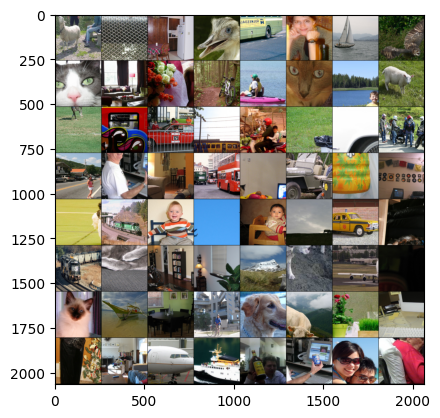

In [7]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(voc_train, k=num)])
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())

In [8]:
class DownConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.conv_1 = nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1)
        self.bn_1 = nn.BatchNorm2d(cout)
        
        self.conv_2 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)

    def forward(self, x):
        x = self.conv_1(x)
        x = F.relu(x, inplace=True)
        x = self.bn_1(x)
        
        x = self.conv_2(x)
        x = F.relu(x, inplace=True)
        x = self.bn_2(x)
        return x

class UpConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.upconv_1 = nn.ConvTranspose2d(cin, cout, kernel_size=2, stride=2)
        self.bn_1 = nn.BatchNorm2d(cout)

        # Cat with through connection happens here, which doubles the number of channels.
        
        self.conv_2 = nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1)
        self.bn_2 = nn.BatchNorm2d(cout)
        
        self.conv_3 = nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1)
        self.bn_3 = nn.BatchNorm2d(cout)

    def forward(self, x, xcat):
        # Cat on channel dim
        x = self.upconv_1(x)
        x = self.bn_1(x)

        tmp = torch.cat((x, xcat), dim=1)
        
        x = self.conv_2(tmp)
        x = F.relu(x, inplace=True)
        x = self.bn_2(x)

        x = self.conv_3(x)
        x = F.relu(x, inplace=True)
        x = self.bn_3(x)
        
        return x
    
class UnetSeg(nn.Module):
    def __init__(self, cin, cout=num_classes, filts=32):
        super().__init__()
        self.l1 = DownConv(cin, filts)
        self.l2 = DownConv(filts, filts*2)
        self.l3 = DownConv(filts*2, filts*4)
        self.l4 = DownConv(filts*4, filts*8)

        self.thru = nn.Sequential(
            nn.Conv2d(filts*8, filts*16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(filts*16),
            nn.Conv2d(filts*16, filts*16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(filts*16)
        )
    
        self.u1 = UpConv(filts*16, filts*8)
        self.u2 = UpConv(filts*8, filts*4)
        self.u3 = UpConv(filts*4, filts*2)
        self.u4 = UpConv(filts*2, filts)
        # Increase the amount of filters at the end of the network
        self.out7 = nn.Conv2d(filts, num_classes, kernel_size=1, stride=1)

    def forward(self, x):
        # Down
        x0 = self.l1(x)
        x1 = self.l2(F.max_pool2d(x0, kernel_size=2))
        x2 = self.l3(F.max_pool2d(x1, kernel_size=2))
        x3 = self.l4(F.max_pool2d(x2, kernel_size=2))

        # xb -> x bottleneck
        xb = self.thru(F.max_pool2d(x3, kernel_size=2))

        # Up
        xu3 = self.u1(xb, x3)
        xu4 = self.u2(xu3, x2)
        xu5 = self.u3(xu4, x1)
        xu6 = self.u4(xu5, x0)

        # Output
        xout = self.out7(xu6)
        return xout

In [10]:
from torchinfo import summary
testmodel = UnetSeg(3, num_classes, filts=8)
lossfn = nn.CrossEntropyLoss()
print(summary(testmodel, (1, 3, 512, 512)))

Layer (type:depth-idx)                   Output Shape              Param #
UnetSeg                                  [1, 2, 512, 512]          --
├─DownConv: 1-1                          [1, 8, 512, 512]          --
│    └─Conv2d: 2-1                       [1, 8, 512, 512]          224
│    └─BatchNorm2d: 2-2                  [1, 8, 512, 512]          16
│    └─Conv2d: 2-3                       [1, 8, 512, 512]          584
│    └─BatchNorm2d: 2-4                  [1, 8, 512, 512]          16
├─DownConv: 1-2                          [1, 16, 256, 256]         --
│    └─Conv2d: 2-5                       [1, 16, 256, 256]         1,168
│    └─BatchNorm2d: 2-6                  [1, 16, 256, 256]         32
│    └─Conv2d: 2-7                       [1, 16, 256, 256]         2,320
│    └─BatchNorm2d: 2-8                  [1, 16, 256, 256]         32
├─DownConv: 1-3                          [1, 32, 128, 128]         --
│    └─Conv2d: 2-9                       [1, 32, 128, 128]         4,640
│   

In [11]:
class ToOneHot(nn.Module):
    def __init__(self, num_classes, trunc_mode='clip'):
        super().__init__()
        self.num_classes = num_classes
        self.trunc_mode = trunc_mode

    def forward(self, x):
        if self.trunc_mode == 'clip':
            # Any class higher than num_classes is set to the highest class number.
            x = torch.clamp_max(x, self.num_classes - 1)
        elif self.trunc_mode == 'background':
            # Any class higher than num_classes is set to background
            x[x > (self.num_classes -1)] = 0
        else:
            raise Exception("Invalid truncation mode")
        
        x = F.one_hot(x.long(), self.num_classes)
        return x.squeeze(1).permute(0, 3, 1, 2)
        

In [12]:
batchsize = 8

train_loader = tud.DataLoader(
    voc_train,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)
val_loader = tud.DataLoader(
    voc_val,
    batch_size=batchsize,
    num_workers=8,
    shuffle=True)

100%|█████████████████████████████████████████| 183/183 [00:03<00:00, 55.54it/s]


Train Loss 0: 0.6282466650009155 
Running val...


100%|████████████████████████████████████████| 182/182 [00:01<00:00, 115.25it/s]


Eval Loss 0: 0.7512365579605103 
Current LR is [0.01]


100%|█████████████████████████████████████████| 183/183 [00:03<00:00, 54.58it/s]


...

Train Loss 47: 0.47267013788223267 
Scheduler already at LR floor of 1e-05


100%|█████████████████████████████████████████| 183/183 [00:03<00:00, 54.62it/s]


Train Loss 48: 0.48414069414138794 
Scheduler already at LR floor of 1e-05


100%|█████████████████████████████████████████| 183/183 [00:03<00:00, 55.06it/s]

Train Loss 49: 0.47639206051826477 
Scheduler already at LR floor of 1e-05
CPU times: user 14min 31s, sys: 28.9 s, total: 15min
Wall time: 3min 3s


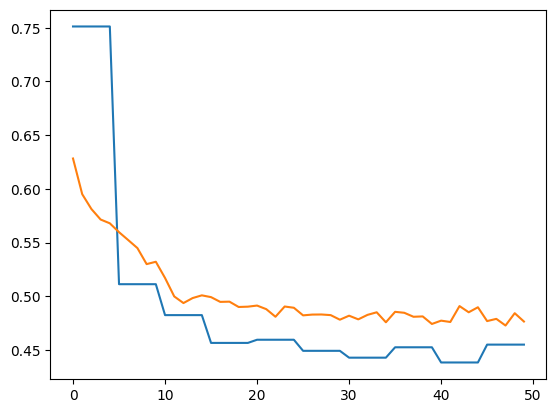

In [15]:
%%time

# model = SimpleSeg(3, num_classes, filts=16).to(device).train()
model = UnetSeg(3, num_classes, filts=16).to(device).train()
onehot_transform = ToOneHot(num_classes, trunc_mode='clip')

lr_floor=1e-5
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
epochs = 50
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

lossfn = nn.CrossEntropyLoss()

train_loss_plot = []
loss_plot = []
try:
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for i, (images, targets) in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            images = images.float().to(device)
            targets = onehot_transform(targets).float().to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets)
            loss.backward()
            train_losses.append(loss.cpu().item())
            optimizer.step()

        train_loss = torch.Tensor(train_losses).mean().item()
        print("Train Loss {}: {} ".format(epoch, train_loss))
        train_loss_plot.append(train_loss)

        if epoch % 5 == 0:
            losses = []
            model.eval()
            correct = 0
            total = len(voc_val)
            print("Running val...")
            with torch.no_grad():
                for i, (images, targets) in enumerate(tqdm(val_loader)):
                    images = images.float().to(device)
                    targets = onehot_transform(targets).float().to(device)
                    outs = model(images)
        
                    loss = lossfn(outs, targets)
                    losses.append(loss.cpu().item())
                        
            eval_loss = torch.Tensor(losses).mean().item()
            print("Eval Loss {}: {} ".format(epoch, eval_loss))
            print("Current LR is {}".format(scheduler.get_last_lr()))
        loss_plot.append(eval_loss)
        
        if scheduler.get_last_lr()[0] > lr_floor:
            scheduler.step()
        else:
            print("Scheduler already at LR floor of {}".format(lr_floor))
        
except KeyboardInterrupt:
    plt.plot(loss_plot)
    plt.plot(train_loss_plot)
    
plt.plot(loss_plot)
plt.plot(train_loss_plot)

In [17]:
from ipywidgets import interact

@interact(index=(0, len(voc_val)), thresh=(0, 1, 0.01))
def draw_preds(index=0, thresh=0.5):
    data, label = voc_val[index]
    label = onehot_transform(label)
    input = data.float().cuda().unsqueeze(0)
    with torch.no_grad():
        model.eval()
        pred = model(input)
        pred = F.softmax(pred, dim=1)
        pred = torch.threshold(pred, thresh, 0)
        pred[pred > 0.001] = 1
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.imshow(data.permute(1,2,0))
    ax1.imshow(label.squeeze()[1], alpha=0.4)
    
    ax2.imshow(data.permute(1,2,0))
    ax2.imshow(pred[0, 1, ...].cpu(), alpha=0.4)


interactive(children=(IntSlider(value=0, description='index', max=1449), FloatSlider(value=0.5, description='t…